In [79]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import scipy as sc
import scipy.stats as stats
from scipy.signal import find_peaks
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.style as mplstyle

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *
from open_data import *

mplstyle.use(["ggplot", "fast"])

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter

In [81]:
data = processed_data_20cm

In [82]:
freqs = list(data.keys())
volts = []

for i in range(len(freqs)):
    volts.append(list(data[freqs[i]].keys()))

In [83]:
for i, f in enumerate(freqs):
        k = estimate_wavenumber(f, 0.2)
        print(f"Estimated wavenumber for {f} Hz: {k:.3f} 1/m")
        for v in volts[i]:
                print(f"Frequency: {f}, Voltage: {v}")
                eta_r1 = data[f][v]["None"]["R1"]
                eta_r2 = data[f][v]["None"]["R2"]
                eta_r3 = data[f][v]["None"]["R3"]

                P0_r1 = eta_r1["P_0"]
                P0_r2 = eta_r2["P_0"]
                P0_r3 = eta_r3["P_0"]

                time_r1 = eta_r1["time"]
                time_r2 = eta_r2["time"]
                time_r3 = eta_r3["time"]

                # Masks where data is not NaN
                mask_r1 = ~P0_r1.isna()
                mask_r2 = ~P0_r2.isna()
                mask_r3 = ~P0_r3.isna()

                # Time arrays cut to match non-NaN data
                time_r1 = time_r1[mask_r1].values
                time_r2 = time_r2[mask_r2].values
                time_r3 = time_r3[mask_r3].values

                # Data arrays with same mask, converted to numpy and sign-flipped
                P0_r1 = (P0_r1[mask_r1].values) * (-1)
                P0_r2 = (P0_r2[mask_r2].values) * (-1)
                P0_r3 = (P0_r3[mask_r3].values) * (-1)

                std_P0_r1 = np.std(P0_r1)
                std_P0_r2 = np.std(P0_r2)
                std_P0_r3 = np.std(P0_r3)

                amp_P0_r1 = np.sqrt(2) * std_P0_r1
                amp_P0_r2 = np.sqrt(2) * std_P0_r2
                amp_P0_r3 = np.sqrt(2) * std_P0_r3

                distance = (1/f) * 250 * 0.8  # 80% of the period in samples, to allow for some variability

                # Comapring variance method to scipy find_peaks
                peak_idx_r1 = sc.signal.find_peaks(P0_r1, height=(0.9*np.sqrt(2)*std_P0_r1, 1.2*np.sqrt(2)*std_P0_r1), distance=distance)[0]
                peak_idx_r2 = sc.signal.find_peaks(P0_r2, height=(0.9*np.sqrt(2)*std_P0_r2, 1.2*np.sqrt(2)*std_P0_r2), distance=distance)[0]
                peak_idx_r3 = sc.signal.find_peaks(P0_r3, height=(0.9*np.sqrt(2)*std_P0_r3, 1.2*np.sqrt(2)*std_P0_r3), distance=distance)[0]

                sc_peaks_r1 = P0_r1[peak_idx_r1]
                sc_peaks_r2 = P0_r2[peak_idx_r2]
                sc_peaks_r3 = P0_r3[peak_idx_r3]

                # Only keep positive peaks
                sc_peaks_r1 = sc_peaks_r1[sc_peaks_r1 > 0]
                sc_peaks_r2 = sc_peaks_r2[sc_peaks_r2 > 0]
                sc_peaks_r3 = sc_peaks_r3[sc_peaks_r3 > 0]

                fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

                # Plot signal vs time
                ax[0].plot(time_r1, P0_r1, color='C0', label=f'Mean = {np.mean(P0_r1):.3g} m')
                ax[1].plot(time_r2, P0_r2, color='C0', label=f'Mean = {np.mean(P0_r2):.3g} m')
                ax[2].plot(time_r3, P0_r3, color='C0', label=f'Mean = {np.mean(P0_r3):.3g} m')

                # Horizontal amplitude lines: use time limits instead of indices
                ax[0].hlines(amp_P0_r1, xmin=time_r1[0], xmax=time_r1[-1], color='k', linestyle='--', label=f"Amplitude = {amp_P0_r1:.4f} m")
                ax[0].hlines(-amp_P0_r1, xmin=time_r1[0], xmax=time_r1[-1], color='k', linestyle='--')

                ax[1].hlines(amp_P0_r2, xmin=time_r2[0], xmax=time_r2[-1], color='k', linestyle='--', label=f"Amplitude = {amp_P0_r2:.4f} m")
                ax[1].hlines(-amp_P0_r2, xmin=time_r2[0], xmax=time_r2[-1], color='k', linestyle='--')

                ax[2].hlines(amp_P0_r3, xmin=time_r3[0], xmax=time_r3[-1], color='k', linestyle='--', label=f"Amplitude = {amp_P0_r3:.4f} m")
                ax[2].hlines(-amp_P0_r3, xmin=time_r3[0], xmax=time_r3[-1], color='k', linestyle='--')

                # Plot peaks 
                ax[0].plot(time_r1[peak_idx_r1], sc_peaks_r1, 'x', color='C1', label=f'Mean individual peaks = {np.mean(sc_peaks_r1):.4f} m \n Count = {len(sc_peaks_r1)}')
                ax[1].plot(time_r2[peak_idx_r2], sc_peaks_r2, 'x', color='C1', label=f'Mean individual peaks = {np.mean(sc_peaks_r2):.4f} m \n Count = {len(sc_peaks_r2)}')
                ax[2].plot(time_r3[peak_idx_r3], sc_peaks_r3, 'x', color='C1', label=f'Mean individual peaks = {np.mean(sc_peaks_r3):.4f} m \n Count = {len(sc_peaks_r3)}')

                ax[0].set_title("R1")
                ax[1].set_title("R2")
                ax[2].set_title("R3")

                for a in ax:
                        a.set_xlabel("Time [s]")
                        a.set_ylabel(r"$\eta$ [m]")

                ax[0].legend(loc='center left')
                ax[1].legend(loc='center left')
                ax[2].legend(loc='center left')

                a = np.mean([np.mean(sc_peaks_r1), np.mean(sc_peaks_r2), np.mean(sc_peaks_r3)])
                fig.suptitle(f"f ={f} Hz, A = {v} V, No plates, ak = {a*k:.4f}, kH = {k*0.2:.4f}")

                plt.tight_layout()
                fr = str(f).replace(".", "")
                am = str(v).replace(".", "")
                plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/amp_P0/f{fr}_a{am}_noplate_P0.png", dpi=100)
                plt.close(fig)

Estimated wavenumber for 1.1 Hz: 5.890 1/m
Frequency: 1.1, Voltage: 0.1
Frequency: 1.1, Voltage: 0.2
Frequency: 1.1, Voltage: 0.3
Estimated wavenumber for 1.2 Hz: 6.662 1/m
Frequency: 1.2, Voltage: 0.1
Frequency: 1.2, Voltage: 0.2
Frequency: 1.2, Voltage: 0.3
Estimated wavenumber for 1.3 Hz: 7.511 1/m
Frequency: 1.3, Voltage: 0.1
Frequency: 1.3, Voltage: 0.2
Frequency: 1.3, Voltage: 0.3
Estimated wavenumber for 1.4 Hz: 8.445 1/m
Frequency: 1.4, Voltage: 0.1
Frequency: 1.4, Voltage: 0.2
Frequency: 1.4, Voltage: 0.3
Estimated wavenumber for 1.5 Hz: 9.474 1/m
Frequency: 1.5, Voltage: 0.1
Frequency: 1.5, Voltage: 0.2
Frequency: 1.5, Voltage: 0.3
Estimated wavenumber for 1.6 Hz: 10.603 1/m
Frequency: 1.6, Voltage: 0.1
Frequency: 1.6, Voltage: 0.2
Frequency: 1.6, Voltage: 0.25
Frequency: 1.6, Voltage: 0.3
Estimated wavenumber for 1.7 Hz: 11.836 1/m
Frequency: 1.7, Voltage: 0.1
Frequency: 1.7, Voltage: 0.2
Frequency: 1.7, Voltage: 0.25
Frequency: 1.7, Voltage: 0.3
Estimated wavenumber for 1.8

In [84]:
for i, f in enumerate(freqs):
        k = estimate_wavenumber(f, 0.2)
        print(f"Estimated wavenumber for {f} Hz: {k:.3f} 1/m")
        for v in volts[i]:
                print(f"Frequency: {f}, Voltage: {v}")
                eta_r1 = data[f][v]["p005"]["R1"]
                eta_r2 = data[f][v]["p005"]["R2"]
                eta_r3 = data[f][v]["p005"]["R3"]

                P0_r1 = eta_r1["P_0"]
                P0_r2 = eta_r2["P_0"]
                P0_r3 = eta_r3["P_0"]

                time_r1 = eta_r1["time"]
                time_r2 = eta_r2["time"]
                time_r3 = eta_r3["time"]

                # Masks where data is not NaN
                mask_r1 = ~P0_r1.isna()
                mask_r2 = ~P0_r2.isna()
                mask_r3 = ~P0_r3.isna()

                # Time arrays cut to match non-NaN data
                time_r1 = time_r1[mask_r1].values
                time_r2 = time_r2[mask_r2].values
                time_r3 = time_r3[mask_r3].values

                # Data arrays with same mask, converted to numpy and sign-flipped
                P0_r1 = (P0_r1[mask_r1].values) * (-1)
                P0_r2 = (P0_r2[mask_r2].values) * (-1)
                P0_r3 = (P0_r3[mask_r3].values) * (-1)

                std_P0_r1 = np.std(P0_r1)
                std_P0_r2 = np.std(P0_r2)
                std_P0_r3 = np.std(P0_r3)

                amp_P0_r1 = np.sqrt(2) * std_P0_r1
                amp_P0_r2 = np.sqrt(2) * std_P0_r2
                amp_P0_r3 = np.sqrt(2) * std_P0_r3

                distance = (1/f) * 250 * 0.8  # 80% of the period in samples, to allow for some variability

                # Comapring variance method to scipy find_peaks
                peak_idx_r1 = sc.signal.find_peaks(P0_r1, height=(0.9*np.sqrt(2)*std_P0_r1, 1.2*np.sqrt(2)*std_P0_r1), distance=distance)[0]
                peak_idx_r2 = sc.signal.find_peaks(P0_r2, height=(0.9*np.sqrt(2)*std_P0_r2, 1.2*np.sqrt(2)*std_P0_r2), distance=distance)[0]
                peak_idx_r3 = sc.signal.find_peaks(P0_r3, height=(0.9*np.sqrt(2)*std_P0_r3, 1.2*np.sqrt(2)*std_P0_r3), distance=distance)[0]

                sc_peaks_r1 = P0_r1[peak_idx_r1]
                sc_peaks_r2 = P0_r2[peak_idx_r2]
                sc_peaks_r3 = P0_r3[peak_idx_r3]

                # Only keep positive peaks
                sc_peaks_r1 = sc_peaks_r1[sc_peaks_r1 > 0]
                sc_peaks_r2 = sc_peaks_r2[sc_peaks_r2 > 0]
                sc_peaks_r3 = sc_peaks_r3[sc_peaks_r3 > 0]

                fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

                # Plot signal vs time
                ax[0].plot(time_r1, P0_r1, color='C0', label=f'Mean = {np.mean(P0_r1):.3g} m')
                ax[1].plot(time_r2, P0_r2, color='C0', label=f'Mean = {np.mean(P0_r2):.3g} m')
                ax[2].plot(time_r3, P0_r3, color='C0', label=f'Mean = {np.mean(P0_r3):.3g} m')

                # Horizontal amplitude lines: use time limits instead of indices
                ax[0].hlines(amp_P0_r1, xmin=time_r1[0], xmax=time_r1[-1], color='k', linestyle='--', label=f"Amplitude = {amp_P0_r1:.4f} m")
                ax[0].hlines(-amp_P0_r1, xmin=time_r1[0], xmax=time_r1[-1], color='k', linestyle='--')

                ax[1].hlines(amp_P0_r2, xmin=time_r2[0], xmax=time_r2[-1], color='k', linestyle='--', label=f"Amplitude = {amp_P0_r2:.4f} m")
                ax[1].hlines(-amp_P0_r2, xmin=time_r2[0], xmax=time_r2[-1], color='k', linestyle='--')

                ax[2].hlines(amp_P0_r3, xmin=time_r3[0], xmax=time_r3[-1], color='k', linestyle='--', label=f"Amplitude = {amp_P0_r3:.4f} m")
                ax[2].hlines(-amp_P0_r3, xmin=time_r3[0], xmax=time_r3[-1], color='k', linestyle='--')

                # Plot peaks 
                ax[0].plot(time_r1[peak_idx_r1], sc_peaks_r1, 'x', color='C1', label=f'Mean individual peaks = {np.mean(sc_peaks_r1):.4f} m \n Count = {len(sc_peaks_r1)}')
                ax[1].plot(time_r2[peak_idx_r2], sc_peaks_r2, 'x', color='C1', label=f'Mean individual peaks = {np.mean(sc_peaks_r2):.4f} m \n Count = {len(sc_peaks_r2)}')
                ax[2].plot(time_r3[peak_idx_r3], sc_peaks_r3, 'x', color='C1', label=f'Mean individual peaks = {np.mean(sc_peaks_r3):.4f} m \n Count = {len(sc_peaks_r3)}')

                ax[0].set_title("R1")
                ax[1].set_title("R2")
                ax[2].set_title("R3")

                for a in ax:
                        a.set_xlabel("Time [s]")
                        a.set_ylabel(r"$\eta$ [m]")

                ax[0].legend(loc='center left')
                ax[1].legend(loc='center left')
                ax[2].legend(loc='center left')

                a = np.mean([np.mean(sc_peaks_r1), np.mean(sc_peaks_r2), np.mean(sc_peaks_r3)])
                fig.suptitle(f"f ={f} Hz, A = {v} V, With plates, ak = {a*k:.4f}, kH = {k*0.2:.4f}")

                plt.tight_layout()
                fr = str(f).replace(".", "")
                am = str(v).replace(".", "")
                plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/amp_P0/f{fr}_a{am}_plate_P0.png", dpi=100)
                plt.close(fig)

Estimated wavenumber for 1.1 Hz: 5.890 1/m
Frequency: 1.1, Voltage: 0.1
Frequency: 1.1, Voltage: 0.2
Frequency: 1.1, Voltage: 0.3
Estimated wavenumber for 1.2 Hz: 6.662 1/m
Frequency: 1.2, Voltage: 0.1
Frequency: 1.2, Voltage: 0.2
Frequency: 1.2, Voltage: 0.3
Estimated wavenumber for 1.3 Hz: 7.511 1/m
Frequency: 1.3, Voltage: 0.1
Frequency: 1.3, Voltage: 0.2
Frequency: 1.3, Voltage: 0.3
Estimated wavenumber for 1.4 Hz: 8.445 1/m
Frequency: 1.4, Voltage: 0.1
Frequency: 1.4, Voltage: 0.2
Frequency: 1.4, Voltage: 0.3
Estimated wavenumber for 1.5 Hz: 9.474 1/m
Frequency: 1.5, Voltage: 0.1
Frequency: 1.5, Voltage: 0.2
Frequency: 1.5, Voltage: 0.3
Estimated wavenumber for 1.6 Hz: 10.603 1/m
Frequency: 1.6, Voltage: 0.1
Frequency: 1.6, Voltage: 0.2
Frequency: 1.6, Voltage: 0.25
Frequency: 1.6, Voltage: 0.3
Estimated wavenumber for 1.7 Hz: 11.836 1/m
Frequency: 1.7, Voltage: 0.1
Frequency: 1.7, Voltage: 0.2
Frequency: 1.7, Voltage: 0.25
Frequency: 1.7, Voltage: 0.3
Estimated wavenumber for 1.8

## Plotting the amplitude distribution

In [85]:
for f in freqs:
    if f in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]
    
    for v in volts:
        eta_no_r1 = data[f][v]["None"]["R1"]
        eta_no_r2 = data[f][v]["None"]["R2"]
        eta_no_r3 = data[f][v]["None"]["R3"]
        
        eta_p_r1 = data[f][v]["p005"]["R1"]
        eta_p_r2 = data[f][v]["p005"]["R2"]
        eta_p_r3 = data[f][v]["p005"]["R3"]

        P0_no_r1 = eta_no_r1["P_0"].values * (-1)
        P0_p_r1 = eta_p_r1["P_0"].values * (-1)
        P3_no_r1 = eta_no_r1["P_3"].values * (-1)
        P3_p_r1 = eta_p_r1["P_3"].values * (-1)

        P0_no_r2 = eta_no_r2["P_0"].values * (-1)
        P0_p_r2 = eta_p_r2["P_0"].values * (-1)
        P3_no_r2 = eta_no_r2["P_3"].values * (-1)
        P3_p_r2 = eta_p_r2["P_3"].values * (-1)

        P0_no_r3 = eta_no_r3["P_0"].values * (-1)
        P0_p_r3 = eta_p_r3["P_0"].values * (-1)
        P3_no_r3 = eta_no_r3["P_3"].values * (-1)
        P3_p_r3 = eta_p_r3["P_3"].values * (-1)

        # Detect peaks
        peak_idx_P0_no_r1 = find_peaks(P0_no_r1, height=(0.9*np.sqrt(2)*np.nanstd(P0_no_r1), 1.2*np.sqrt(2)*np.nanstd(P0_no_r1)), distance=90)[0]
        peak_idx_P3_no_r1 = find_peaks(P3_no_r1, height=(0.9*np.sqrt(2)*np.nanstd(P3_no_r1), 1.2*np.sqrt(2)*np.nanstd(P3_no_r1)), distance=90)[0]
        peak_idx_P0_p_r1 = find_peaks(P0_p_r1, height=(0.9*np.sqrt(2)*np.nanstd(P0_p_r1), 1.2*np.sqrt(2)*np.nanstd(P0_p_r1)), distance=90)[0]
        peak_idx_P3_p_r1 = find_peaks(P3_p_r1, height=(0.9*np.sqrt(2)*np.nanstd(P3_p_r1), 1.2*np.sqrt(2)*np.nanstd(P3_p_r1)), distance=90)[0]

        peak_idx_P0_no_r2 = find_peaks(P0_no_r2, height=(0.9*np.sqrt(2)*np.nanstd(P0_no_r2), 1.2*np.sqrt(2)*np.nanstd(P0_no_r2)), distance=90)[0]
        peak_idx_P3_no_r2 = find_peaks(P3_no_r2, height=(0.9*np.sqrt(2)*np.nanstd(P3_no_r2), 1.2*np.sqrt(2)*np.nanstd(P3_no_r2)), distance=90)[0]
        peak_idx_P0_p_r2 = find_peaks(P0_p_r2, height=(0.9*np.sqrt(2)*np.nanstd(P0_p_r2), 1.2*np.sqrt(2)*np.nanstd(P0_p_r2)), distance=90)[0]
        peak_idx_P3_p_r2 = find_peaks(P3_p_r2, height=(0.9*np.sqrt(2)*np.nanstd(P3_p_r2), 1.2*np.sqrt(2)*np.nanstd(P3_p_r2)), distance=90)[0]

        peak_idx_P0_no_r3 = find_peaks(P0_no_r3, height=(0.9*np.sqrt(2)*np.nanstd(P0_no_r3), 1.2*np.sqrt(2)*np.nanstd(P0_no_r3)), distance=90)[0]
        peak_idx_P3_no_r3 = find_peaks(P3_no_r3, height=(0.9*np.sqrt(2)*np.nanstd(P3_no_r3), 1.2*np.sqrt(2)*np.nanstd(P3_no_r3)), distance=90)[0]
        peak_idx_P0_p_r3 = find_peaks(P0_p_r3, height=(0.9*np.sqrt(2)*np.nanstd(P0_p_r3), 1.2*np.sqrt(2)*np.nanstd(P0_p_r3)), distance=90)[0]
        peak_idx_P3_p_r3 = find_peaks(P3_p_r3, height=(0.9*np.sqrt(2)*np.nanstd(P3_p_r3), 1.2*np.sqrt(2)*np.nanstd(P3_p_r3)), distance=90)[0]

        # Get amplitudes
        amp_P0_no_r1 = P0_no_r1[peak_idx_P0_no_r1]
        amp_P3_no_r1 = P3_no_r1[peak_idx_P3_no_r1]
        amp_P0_p_r1 = P0_p_r1[peak_idx_P0_p_r1]
        amp_P3_p_r1 = P3_p_r1[peak_idx_P3_p_r1]

        amp_p0_no_r2 = P0_no_r2[peak_idx_P0_no_r2]
        amp_p3_no_r2 = P3_no_r2[peak_idx_P3_no_r2]
        amp_p0_p_r2 = P0_p_r2[peak_idx_P0_p_r2]
        amp_p3_p_r2 = P3_p_r2[peak_idx_P3_p_r2]

        amp_p0_no_r3 = P0_no_r3[peak_idx_P0_no_r3]
        amp_p3_no_r3 = P3_no_r3[peak_idx_P3_no_r3]
        amp_p0_p_r3 = P0_p_r3[peak_idx_P0_p_r3]
        amp_p3_p_r3 = P3_p_r3[peak_idx_P3_p_r3]

        amp_p0_no = np.concatenate([amp_P0_no_r1, amp_p0_no_r2, amp_p0_no_r3])
        amp_p0_no = amp_p0_no[amp_p0_no > 0]
        amp_p3_no = np.concatenate([amp_P3_no_r1, amp_p3_no_r2, amp_p3_no_r3])
        amp_p3_no = amp_p3_no[amp_p3_no > 0]
        amp_p0_p = np.concatenate([amp_P0_p_r1, amp_p0_p_r2, amp_p0_p_r3])
        amp_p0_p = amp_p0_p[amp_p0_p > 0]
        amp_p3_p = np.concatenate([amp_P3_p_r1, amp_p3_p_r2, amp_p3_p_r3])
        amp_p3_p = amp_p3_p[amp_p3_p > 0]

        fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
        ax[0].hist(amp_p0_no, bins=20, density=True, alpha=0.5, color='C0', label='P0')
        ax[0].hist(amp_p3_no, bins=20, density=True, alpha=0.5, color='C1', label='P3')

        ax[0].axvline(amp_p0_no.mean(), color='C0', linestyle='--', label=rf'$\mu_{{P0}}$= {amp_p0_no.mean():.4f} m')
        ax[0].axvline(amp_p3_no.mean(), color='C1', linestyle='--', label=rf'$\mu_{{P3}}$= {amp_p3_no.mean():.4f} m')

        ax[0].set_title(f"No Plates")
        ax[0].set_ylabel("Density")
        ax[0].legend(ncol=2)

        ax[1].hist(amp_p0_p, bins=20, density=True, alpha=0.5, color='C2', label='P0')
        ax[1].hist(amp_p3_p, bins=20, density=True, alpha=0.5, color='C3', label='P3')

        ax[1].axvline(amp_p0_p.mean(), color='C2', linestyle='--', label=rf'$\mu_{{P0}}$= {amp_p0_p.mean():.4f} m')
        ax[1].axvline(amp_p3_p.mean(), color='C3', linestyle='--', label=rf'$\mu_{{P3}}$= {amp_p3_p.mean():.4f} m')

        ax[1].set_title(f"With Plates")
        ax[1].set_xlabel("Amplitude [m]")
        ax[1].set_ylabel("Density")
        ax[1].legend(ncol=2)

        fig.suptitle(f"Frequency: {f} Hz, Voltage: {v} V")

        freq = str(f).replace(".", "")
        amp = str(v).replace(".", "")

        plt.tight_layout()
        plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/amp_dist/amp_dist_f{freq}_a{amp}.png", dpi=200)
        plt.close(fig)

## Wilcoxon signed rank test

In [86]:
def wilcoxon_signed_rank_test_20cm(freq, cond):
    if freq in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]

    results = {}
    for v in volts:
        for r in ["R1", "R2", "R3"]:
            df = data[freq][v][cond][r]

            # Keep time alignment
            eta_P0 = df['P_0'].values * -1
            eta_P3 = df['P_3'].values * -1  # includes NaNs

            distance = (1/freq) * 250 * 0.8  # 80% of the period in samples, to allow for some variability

            # Detect peaks
            peak_idx_P0 = find_peaks(eta_P0, height=(0.9*np.sqrt(2)*np.nanstd(eta_P0), 1.2*np.sqrt(2)*np.nanstd(eta_P0)), distance=distance)[0]
            peak_idx_P3 = find_peaks(eta_P3, height=(0.9*np.sqrt(2)*np.nanstd(eta_P3), 1.2*np.sqrt(2)*np.nanstd(eta_P3)), distance=distance)[0]

            # Indices where P_3 has data
            p3_indices = np.where(~np.isnan(eta_P3))[0]

            p3_start = p3_indices[0]
            p3_end   = p3_indices[-1]

            # Keep only P_0 peaks that lie inside the valid time window for P_3
            peak_idx_P0 = [i for i in peak_idx_P0 if (i >= p3_start) and (i <= p3_end)]

            # Get amplitudes
            amp_P0 = eta_P0[peak_idx_P0]
            amp_P3 = eta_P3[peak_idx_P3]

            # Make same length by truncating to min length
            n = min(len(amp_P0), len(amp_P3))
            amp_P0 = amp_P0[:n]
            amp_P3 = amp_P3[:n]

            # Keep only positive amplitudes
            mask_pos = (amp_P0 > 0) & (amp_P3 > 0)
            amp_P0 = amp_P0[mask_pos]
            amp_P3 = amp_P3[mask_pos]

            amp_diff = np.round(amp_P0 - amp_P3, decimals=4)
            stat, p_value = stats.wilcoxon(amp_diff, alternative="greater")

            # Store results in a dataframe for later analysis
            results[(freq, v, cond, r)] = {
                'statistic': stat,
                'p_value': p_value,
                'n': n
            }      

        df = pd.DataFrame.from_dict(results, orient='index')
    return df

In [87]:
f11_wilcoxon = wilcoxon_signed_rank_test_20cm(1.1, 'p005')
f12_wilcoxon = wilcoxon_signed_rank_test_20cm(1.2, 'p005')
f13_wilcoxon = wilcoxon_signed_rank_test_20cm(1.3, 'p005')
f14_wilcoxon = wilcoxon_signed_rank_test_20cm(1.4, 'p005')
f15_wilcoxon = wilcoxon_signed_rank_test_20cm(1.5, 'p005')
f16_wilcoxon = wilcoxon_signed_rank_test_20cm(1.6, 'p005')
f17_wilcoxon = wilcoxon_signed_rank_test_20cm(1.7, 'p005')
f18_wilcoxon = wilcoxon_signed_rank_test_20cm(1.8, 'p005')

f11_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.1, "None")
f12_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.2, "None")
f13_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.3, "None")
f14_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.4, "None")
f15_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.5, "None")
f16_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.6, "None")
f17_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.7, "None")
f18_wilcoxon_no = wilcoxon_signed_rank_test_20cm(1.8, "None")

In [88]:
wilcoxon_p = pd.concat([f11_wilcoxon, f12_wilcoxon, f13_wilcoxon, f14_wilcoxon, f15_wilcoxon, f16_wilcoxon, f17_wilcoxon, f18_wilcoxon])
wilcoxon_no = pd.concat([f11_wilcoxon_no, f12_wilcoxon_no, f13_wilcoxon_no, f14_wilcoxon_no, f15_wilcoxon_no, f16_wilcoxon_no, f17_wilcoxon_no, f18_wilcoxon_no])

Text(0.5, 0.98, 'Distribution of Wilcoxon Signed-Rank Test P-Values (D = 0.2 m)')

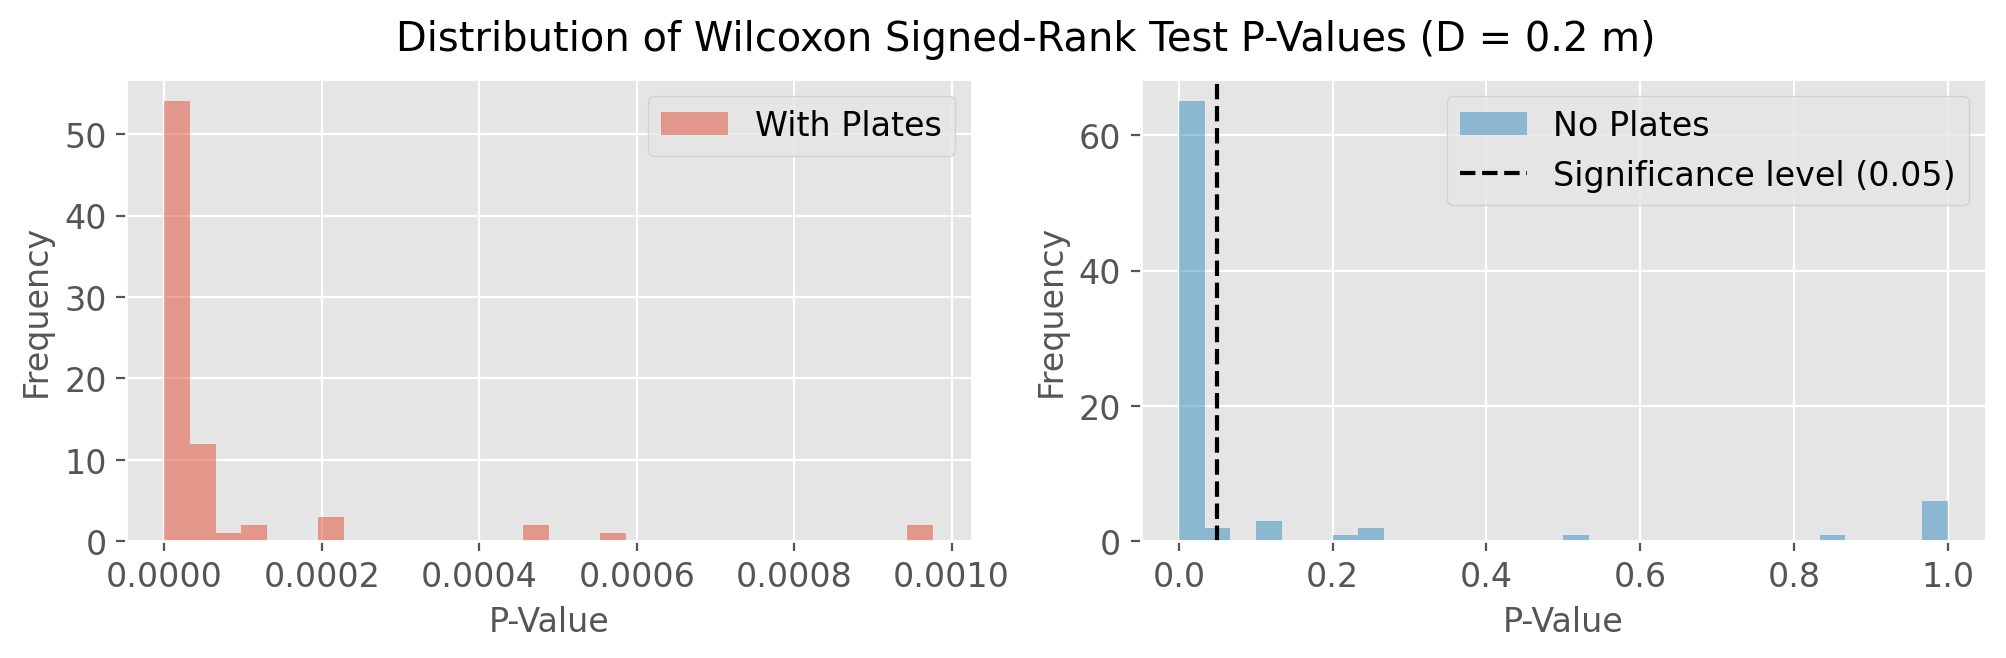

In [89]:
fig, ax = plt.subplots(1, 2,figsize=(12, 3))

ax[0].hist(wilcoxon_p['p_value'], bins=30, alpha=0.5, color='C0', label='With Plates')
ax[1].hist(wilcoxon_no['p_value'], bins=30, alpha=0.5, color='C1', label='No Plates')
ax[1].axvline(0.05, color='k', linestyle='--', label='Significance level (0.05)')
for a in ax:
    a.set_xlabel('P-Value')
    a.set_ylabel('Frequency')
    a.legend()
fig.suptitle("Distribution of Wilcoxon Signed-Rank Test P-Values (D = 0.2 m)")

In [90]:
print("Cases with no significant difference (p > 0.05):")
print("With Plates:")
print(wilcoxon_p[wilcoxon_p['p_value'] > 0.05])
print("\nNo Plates:")
print(wilcoxon_no[wilcoxon_no['p_value'] > 0.05])

Cases with no significant difference (p > 0.05):
With Plates:
Empty DataFrame
Columns: [statistic, p_value, n]
Index: []

No Plates:
                  statistic   p_value   n
1.2 0.30 None R1       59.0  0.522747  16
              R2       48.0  0.850040  16
              R3       26.0  0.973743  16
1.5 0.20 None R1       40.0  1.000000  41
              R2        0.0  1.000000  41
              R3        3.0  1.000000  41
    0.30 None R3      266.0  0.974127  41
1.6 0.30 None R2        6.0  0.125000   3
1.7 0.30 None R1      867.5  0.206605  56
              R3      321.5  0.991699  48
1.8 0.10 None R1      815.0  0.264873  56
    0.25 None R2        6.0  0.125000   3
    0.30 None R1        3.0  0.250000   2
              R2        6.0  0.125000   3
              R3       10.0  0.062500   4
